PROGETTO 2

Il dataset Linnerud presenta un problema di regressione Multi-Target (3 target totali: Weight, Waist, Pulse).
Addestrare e confrontare alcuni modelli di regressione sul dataset, riducendo il
problema da Multi-Target a Single-Target tramite

1. PCA
2. selezione manuale di un singolo target

1 Data Exploration & Preprocessing
    • Caricamento e Analisi del dataset e fornire un’analisi descrittiva iniziale (i.e. df.describe())
    • Standardization delle feature (X) per garantire che tutti gli attributi abbiano media zero e deviazione standard unitaria

2 Target Engineering
    Trasformare il problema Multi-Target in due distinti problemi Single-Target da confrontare:
        • PCA (Target Composto)
            – Applicare la PCA alla matrice dei target standardizzata e mantenere PC1
        • Manuale (Target Selezionato)
            – Selezionare il target Waist dalla matrice dei target standardizzata come singolo target rappresentativo 1

3 Addestramento & Valutazione
    Addestrare i tre modelli di regressione (Linear Regression, Ridge, Lasso) su entrambi gli scenari di target ridotto con PCA e selezione manuale, utilizzando il set di feature completo e standardizzato:
        • Definire e inizializzare i tre modelli di regressione (Lineare, Ridge con α = 1.0, Lasso con α = 0.1)
        • Eseguire l’addestramento su tutto il dataset per entrambi gli scenari
        • Valutare e memorizzare i risultati come Mean Squared Error e R2 Score per ogni combinazione di modello e scenario

4 Analisi & Visualizzazione
    • Applicare la PCA al set di feature standardizzato e mantenere le due componenti principali PC1 e PC2 per la visualizzazione 2D
    • Creare un grafico di dispersione in cui:
        – L’asse X `e il PC1 delle Feature
        – L’asse Y `e la PCA con n components=1
        – Tracciare le tre rette di regressione (Lineare, Ridge, Lasso) ri-addestrate sulla sola PC1 delle Feature, includendo il loro rispettivo R2 Score finale nell’etichetta

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.datasets import load_linnerud
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, r2_score

1 Data Exploration & Preprocessing
    • Caricamento e Analisi del dataset e fornire un’analisi descrittiva iniziale (i.e. df.describe())
    • Standardization delle feature (X) per garantire che tutti gli attributi abbiano media zero e deviazione standard unitaria

In [91]:
data=load_linnerud()
#print(data.DESCR)
print(data.feature_names)
print(len(data.feature_names))

['Chins', 'Situps', 'Jumps']
3


In [92]:
X,y=pd.DataFrame(data.data), pd.DataFrame(data.target)
print(X.shape)   
df=pd.DataFrame(X,columns=data.feature_names)
df.describe()

(20, 3)


,Chins,Situps,Jumps
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


• Standardization delle feature (X) per garantire che tutti gli attributi abbiano media zero e deviazione standard unitaria

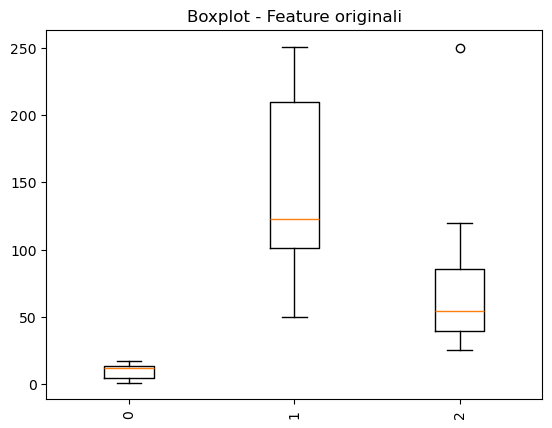

In [93]:
plt.boxplot(X)
plt.xticks(range(1,len(X.columns)+1), X.columns,rotation=90)
plt.title("Boxplot - Feature originali")
plt.show()

In [94]:
scaler=StandardScaler()
X_std=scaler.fit_transform(X)

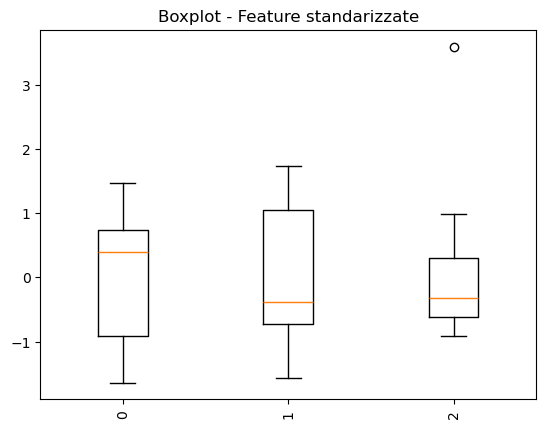

In [95]:
plt.boxplot(X_std)
plt.xticks(range(1,len(X.columns)+1), X.columns,rotation=90)
plt.title("Boxplot - Feature standarizzate")
plt.show()

2 Target Engineering
    Trasformare il problema Multi-Target in due distinti problemi Single-Target da confrontare:
        • PCA (Target Composto)
            – Applicare la PCA alla matrice dei target standardizzata e mantenere PC1
        • Manuale (Target Selezionato)
            – Selezionare il target Waist dalla matrice dei target standardizzata come singolo target rappresentativo 1


        • PCA (Target Composto)
            – Applicare la PCA alla matrice dei target standardizzata e mantenere PC1

In [96]:
#Standarizzo le y
scaler=StandardScaler()
y_std=scaler.fit_transform(y)

#dopo aver applicato la standarizzazione delle feature, posso applicare la PCA per una riduzione dimensionale
pca=PCA() #non ho definito n_components, quindi PCA calcola tante componenti quante sono le feature 
pca.fit(y_std) #trova PC1, PC2, PC3, PC4, ecc con PC1 e PC2 con massima varianza

exp_var=pca.explained_variance_ratio_  #contiene quanta varianza del dataset spiega ogni componente PC
cum_var=np.cumsum(exp_var) #somma cumulativa
print(f" varianza: {exp_var}")
print(f" varianza cumulativa: {cum_var}")

#mantengo solo PC1
pca=PCA(n_components=1) #definisco n_components=1
y_pca=pca.fit_transform(y_std)
#print(y_pca)

 varianza: [0.70137682 0.25540925 0.04321393]
 varianza cumulativa: [0.70137682 0.95678607 1.        ]


        • Manuale (Target Selezionato)
            – Selezionare il target Waist dalla matrice dei target standardizzata come singolo target rappresentativo 1

In [97]:
print(data.target_names)
y_sel=y_std[:,1]

['Weight', 'Waist', 'Pulse']


3 Addestramento & Valutazione
    Addestrare i tre modelli di regressione (Linear Regression, Ridge, Lasso) su entrambi gli scenari di target ridotto con PCA e selezione manuale, utilizzando il set di feature completo e standardizzato:
        • Definire e inizializzare i tre modelli di regressione (Lineare, Ridge con α = 1.0, Lasso con α = 0.1)
        • Eseguire l’addestramento su tutto il dataset per entrambi gli scenari
        • Valutare e memorizzare i risultati come Mean Squared Error e R2 Score per ogni combinazione di modello e scenario

In [113]:
models={
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso()
}
risultati=[]
for tipo_dati, y_target in [("PCA", y_pca), ("Manual", y_sel)]:
    #print(f"\n=== Dati: {tipo_dati} ===")
    for name, model in models.items():
        
        model.fit(X_std, y_target)
        y_pred = model.predict(X_std)
        print(f"\n{name}")
        mae = mean_absolute_error(y_target, y_pred)
        r2 = r2_score(y_target, y_pred)
        risultati.append([tipo_dati, name, mae.__round__(4), r2.__round__(4)])
        #print(f"{name} -> MAE: {mae:.4f} | R²: {r2:.4f}")

        for f, val in zip(data.feature_names, model.coef_):
            print(f"{f}: {val}")
for r in risultati:
    print(r)


Linear
Chins: [-0.21063241 -1.01281087  0.49918489]

Ridge
Chins: -0.24179375244128035
Situps: -0.8870958857610264
Jumps: 0.41000400993631797

Lasso
Chins: -0.0
Situps: -0.0
Jumps: -0.0

Linear
Chins: -0.22596508169110172
Situps: -0.7881778997807418
Jumps: 0.4479785615041866

Ridge
Chins: -0.24448098848462238
Situps: -0.6907965005000736
Jumps: 0.37332360606386644

Lasso
Chins: -0.0
Situps: -0.0
Jumps: -0.0
['PCA', 'Linear', 0.8342, 0.397]
['PCA', 'Ridge', 0.8186, 0.3936]
['PCA', 'Lasso', 1.1365, 0.0]
['Manual', 'Linear', 0.4939, 0.5478]
['Manual', 'Ridge', 0.4931, 0.5433]
['Manual', 'Lasso', 0.7177, 0.0]


MAE errore medio al quadrato
più è basso meglio è, pertanto con i dati originali ho una situazione migliore rispetto alla PCA
R2 quanto il modello spiega i dati
in nessun caso ho una situazione perfetta o buona, i valori maggiori (interno allo 0.54) si ottengono con i dati originali e non con la PCA
Riassumento PCA, comprime il target ma peggiora le perfomance
Il target scelto è più interpretabile e migliore della PCA1
Lasso è da escludere come modello perchè ha R2=0
Ridge ha valori leggermente migliori rispetto alla regressione lineare ma porta pochissimo beneficio, quasi nullo pertanto è inutile in questa situazione
Dataset veramente piccolo (20 righe) quindi PCA porta ad una perdita di informazione importante

4 Analisi & Visualizzazione
    • Applicare la PCA al set di feature standardizzato e mantenere le due componenti principali PC1 e PC2 per la visualizzazione 2D
    • Creare un grafico di dispersione in cui:
        – L’asse X `e il PC1 delle Feature
        – L’asse Y `e la PCA con n components=1
        – Tracciare le tre rette di regressione (Lineare, Ridge, Lasso) ri-addestrate sulla sola PC1 delle Feature, includendo il loro rispettivo R2 Score finale nell’etichetta

    • Applicare la PCA al set di feature standardizzato e mantenere le due componenti principali PC1 e PC2 per la visualizzazione 2D

In [114]:
pca=PCA() #non ho definito n_components, quindi PCA calcola tante componenti quante sono le feature 
pca.fit(X_std) #trova PC1, PC2, PC3, PC4, ecc con PC1 e PC2 con massima varianza

exp_var=pca.explained_variance_ratio_  #contiene quanta varianza del dataset spiega ogni componente PC
cum_var=np.cumsum(exp_var) #somma cumulativa
print(f" varianza: {exp_var}")
print(f" varianza cumulativa: {cum_var}")

 varianza: [0.74814431 0.16834322 0.08351247]
 varianza cumulativa: [0.74814431 0.91648753 1.        ]


con 2 PCA ottengo quadi il 91,65%, ottimo

In [120]:
#mantengo solo PC1 e PC2
pca=PCA(n_components=2) #definisco n_components=2
X_pca=pca.fit_transform(X_std)
#print(X_pca)

    • Creare un grafico di dispersione in cui:
        – L’asse X `e il PC1 delle Feature
        – L’asse Y `e la PCA con n components=1
        – Tracciare le tre rette di regressione (Lineare, Ridge, Lasso) ri-addestrate sulla sola PC1 delle Feature, includendo il loro rispettivo R2 Score finale nell’etichetta

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],label="X_PCA",alpha=0.4)
#plt.scatter(df["petal length (cm)"],y_pred,label="Predetti",alpha=0.4, color="red")
plt.title("Relazione Mean radius - Classe")
plt.xlabel("Mean radius")
plt.ylabel("Class")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

SyntaxError: unmatched ')' (969993960.py, line 2)